# Cycle envelope: fixed design point swept across flight conditions

This is **not** an off-design performance model. `TurbofanDesignPoint`'s
pressure ratios, turbine entry temperature and mass flow are fixed design
inputs, not quantities that respond to throttle or flight condition — see
the project README's Outstanding section, "Off-design performance." A real
off-design study needs compressor maps and part-throttle matching
(corrected mass flow and pressure ratio moving together along a
constant-speed line), which this project does not have.

What this notebook *does* do, honestly: re-solve the exact reference-design
cycle (same pressure ratios, same TET, same mass flow) at a grid of
Mach numbers and altitudes, and see how thrust and TSFC change from ram
effects alone, with everything else about the engine held fixed. That's a
real, useful thing to look at — it just isn't the same claim as "how would
this engine perform off-design," and the plots below say so.

## Setup

Imports `src.cycle` directly from the project this notebook lives
alongside — no package install, matching how `build.py` and the test
suite already import it.

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, str(Path.cwd().parent))

from src.cycle import TurbofanDesignPoint, solve_cycle

In [2]:
# Every design input except altitude and mach held at the reference
# design's values (see ../README.md, "Reference design point").
REFERENCE_KW = dict(
    core_mass_flow=40.0,
    bypass_ratio=6.0,
    fan_pressure_ratio=1.6,
    booster_pressure_ratio=1.6,
    hpc_pressure_ratio=14.0,
    turbine_entry_temperature=1650.0,
)

# mach starts at 0.05, not 0 -- TurbofanDesignPoint requires 0 < mach < 1.2
# (this is a subsonic-intake model; see cycle.py's __post_init__).
machs = np.linspace(0.05, 0.85, 10)
altitudes = [0, 5000, 10668, 15000]  # m; 10668 m = 35,000 ft, the reference altitude

In [3]:
# Sweep every (altitude, mach) combination. solve_cycle can legitimately
# raise ValueError at extreme points (e.g. a turbine asked for more work
# than its inlet enthalpy has available) -- caught and recorded as NaN
# rather than silently dropped, so a gap in the plot means something, not
# a bug in this notebook. Across this specific grid nothing actually
# raises, but the guard stays because the grid above was chosen to sit in
# a plausible range, not because failure is provably impossible everywhere.
results = {alt: {'thrust_kn': [], 'tsfc': [], 'thermal_eff': []} for alt in altitudes}
failures = []

for alt in altitudes:
    for m in machs:
        try:
            design = TurbofanDesignPoint(altitude=float(alt), mach=float(m), **REFERENCE_KW)
            cycle = solve_cycle(design)
            results[alt]['thrust_kn'].append(cycle.net_thrust / 1000.0)
            results[alt]['tsfc'].append(cycle.tsfc_g_per_kns)
            results[alt]['thermal_eff'].append(cycle.thermal_efficiency * 100.0)
        except ValueError as e:
            results[alt]['thrust_kn'].append(np.nan)
            results[alt]['tsfc'].append(np.nan)
            results[alt]['thermal_eff'].append(np.nan)
            failures.append((alt, round(float(m), 3), str(e)))

if failures:
    print(f'{len(failures)} point(s) failed to solve:')
    for f in failures:
        print(' ', f)
else:
    print('Every point in the grid solved.')

Every point in the grid solved.


## Net thrust vs. Mach

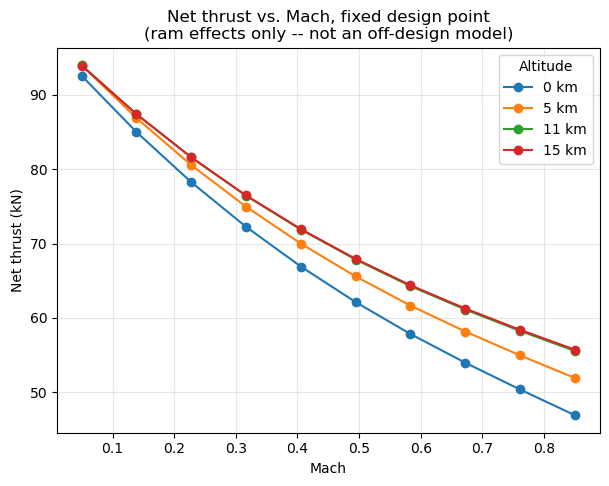

In [4]:
fig, ax = plt.subplots(figsize=(7, 5))
for alt in altitudes:
    ax.plot(machs, results[alt]['thrust_kn'], marker='o', label=f'{alt/1000:.0f} km')
ax.set_xlabel('Mach')
ax.set_ylabel('Net thrust (kN)')
ax.set_title('Net thrust vs. Mach, fixed design point\n(ram effects only -- not an off-design model)')
ax.legend(title='Altitude')
ax.grid(alpha=0.3)
plt.show()

**Thrust falls with Mach at every altitude** — expected: ram drag
(`total_intake_mass_flow * v0`) grows with freestream velocity faster than
gross thrust does, at a fixed design point.

**Thrust does *not* fall much with altitude at a fixed Mach** — this is
the tell that this is a fixed-design sweep, not a real off-design model.
A real engine's mass flow drops with altitude because it's set by air
density at a fixed physical flow area; here, `core_mass_flow` is a
constant design *input* (40 kg/s, always), so the model never represents
that effect. The curves sitting almost on top of each other above altitude
5 km is the model telling you what it doesn't know, not a genuine result
about this engine.

## TSFC vs. Mach

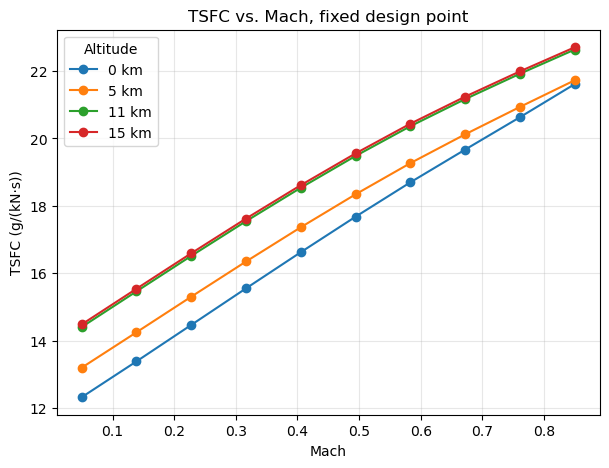

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for alt in altitudes:
    ax.plot(machs, results[alt]['tsfc'], marker='o', label=f'{alt/1000:.0f} km')
ax.set_xlabel('Mach')
ax.set_ylabel('TSFC (g/(kN\u00b7s))')
ax.set_title('TSFC vs. Mach, fixed design point')
ax.legend(title='Altitude')
ax.grid(alpha=0.3)
plt.show()

## Sanity check against the published reference design

In [6]:
# Sanity check: the grid point nearest the actual reference design
# (mach=0.78, altitude=10668 m) should land close to the published
# 57.67 kN / 22.07 g/(kN*s) in ../README.md -- it won't match exactly,
# since 0.78 isn't exactly one of the swept mach values, but it should be
# close given how gently these curves move near that point.
design = TurbofanDesignPoint(altitude=10668.0, mach=0.78, **REFERENCE_KW)
cycle = solve_cycle(design)
print(f'At the exact reference design point:')
print(f'  net thrust  = {cycle.net_thrust/1000:.2f} kN   (README: 57.67 kN)')
print(f'  TSFC        = {cycle.tsfc_g_per_kns:.2f} g/(kN*s)   (README: 22.07 g/(kN*s))')

At the exact reference design point:
  net thrust  = 57.67 kN   (README: 57.67 kN)
  TSFC        = 22.07 g/(kN*s)   (README: 22.07 g/(kN*s))
